In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pymc as pm
import pymc_extras as pmx
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import matplotlib.cm as cm
import arviz as az
from sklearn.preprocessing import StandardScaler
import pytensor.tensor as pt
import matplotlib.cm as cm
import regionmask
import cartopy.crs as ccrs
from geopy.geocoders import Nominatim
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pymc import Minibatch
import seaborn as sns
random_seed=123
np.random.seed(random_seed)
import os,sys,glob
from importlib import reload

In [2]:
import logging
# Set PyMC logger to WARNING or ERROR to suppress info messages
logger = logging.getLogger("pymc")
logger.setLevel(logging.WARNING)

In [4]:
def model_type(index):
    MODELS={}
    MODELS["AnnualMean"]="Gamma"
    MODELS["RX1day"] = "GEV"
    MODELS["RX5day"] = "GEV"
    MODELS["R50"] = "Poisson"

# Import model builders

In [5]:
from trend_detector import ar6models,plotting, spatial


Hypothesis: discontinuities over ocean but not land (because land is better validated)

In [6]:
from trend_detector.io import get_data_path
data_dir = get_data_path("ar6_regions")
REALM_DICT = {}

for realm in ["land", "ocean"]:
    realm_path = data_dir /realm  # pathlib Path object
    filenames = os.listdir(realm_path)
    
    regions = np.unique(
        sorted([f.split("_")[-1].split(".nc")[0] for f in filenames])
    )
    
    for region in regions:
        REALM_DICT[region] = realm

In [7]:
land_regions = regionmask.defined_regions.ar6.land.abbrevs
ocean_regions = regionmask.defined_regions.ar6.ocean.abbrevs

In [8]:

RX1day_land_ens=[]
for region in land_regions:
    RX1day_land_ens+=[ar6models.get_regional_data(region,"RX1day").expand_dims({"region":[region]})]
RX1day_land=xr.concat(RX1day_land_ens,dim="region")

## Land RX1day climatologies

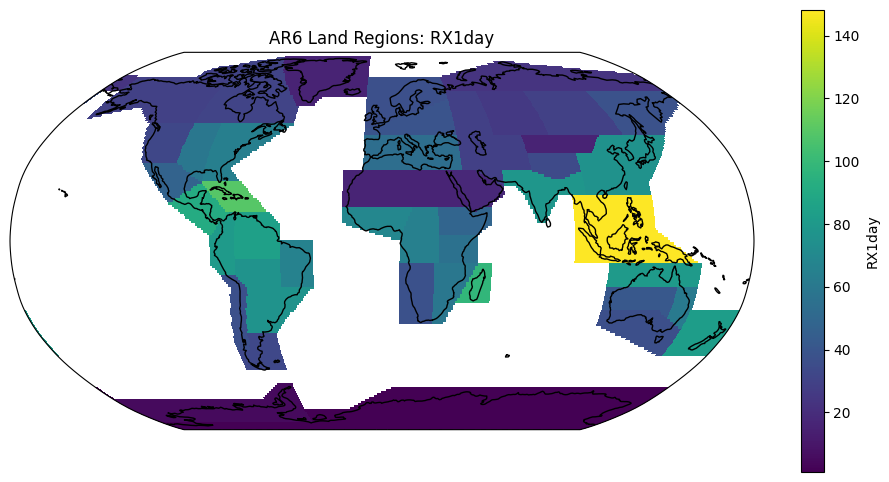

In [9]:
fig=plotting.plot_ar6_land(RX1day_land.mean(dim="time"))

## Calculate the trends

In [10]:
with pm.Model() as spatialtrendmodel:
    params=spatial.build_spatial_GEV_trend_model(spatialtrendmodel,RX1day_land)
    spacetrace=pm.sample()

Output()

# North-south divide
Trends in Rx1day are positive in NH and negative in SH.  This is probably an artifact of the TRMM/GPM changeover!

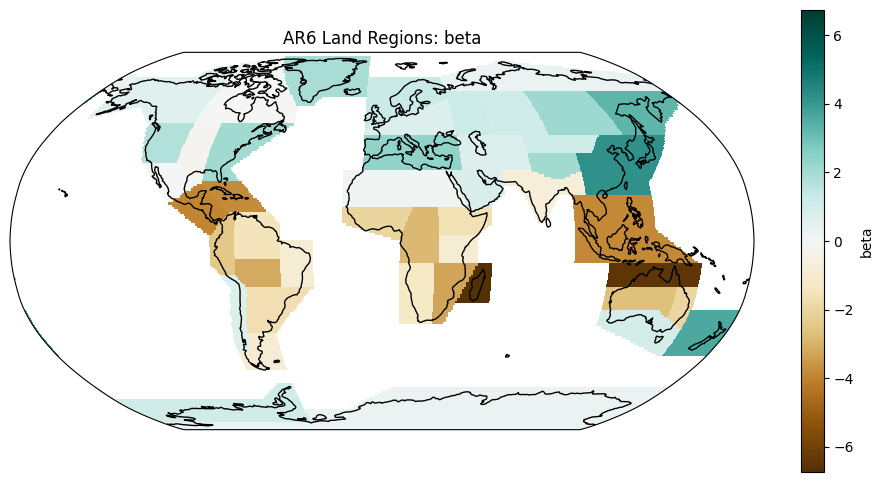

In [11]:
X=spacetrace.posterior.beta.mean(dim=("chain","draw"))
tmp=plotting.plot_ar6_land(X,cmap=cm.BrBG)

## Southern Hemisphere
First let's look at the negative trends in the SH.

In [12]:
negregions=X.region[X.values<-0.25]
negland=RX1day_land.sel(region=negregions)


Are they "significant"?  By which I mean: is their posterior mass substantially shifted away from zero? For example, given the trend model and the IMERG data, I'm 77% confident that there's a negative trend in South Asia (SAS).  But I'm 100% confident there's a negative trend over the South American monsoon region.

array([<Axes: title={'center': 'beta\nSAS'}>,
       <Axes: title={'center': 'beta\nSAM'}>], dtype=object)

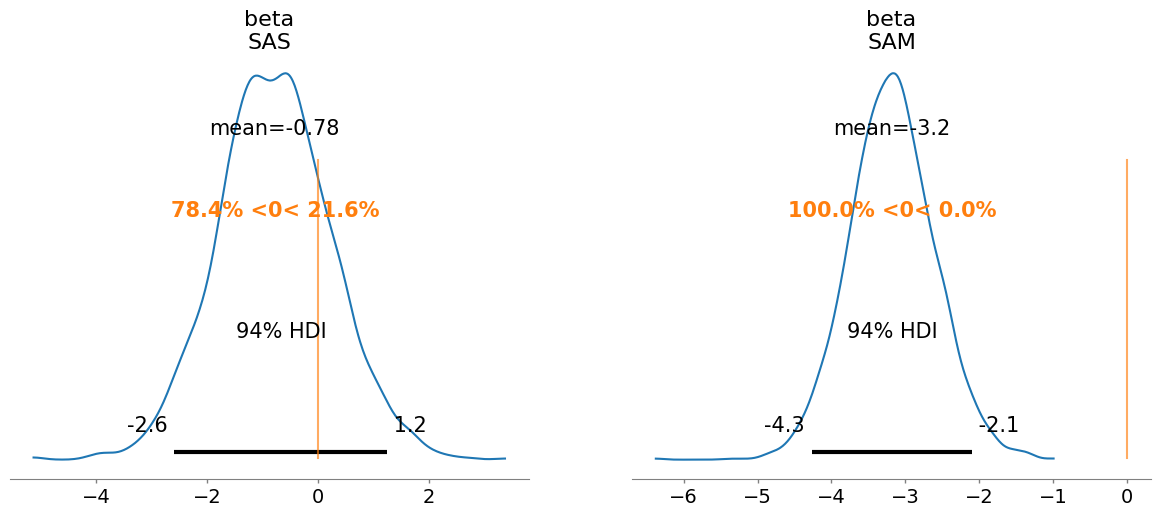

In [13]:
az.plot_posterior(spacetrace.posterior.beta.sel(region=["SAS","SAM"]),ref_val=0)

For reference, here are all the trend posteriors.

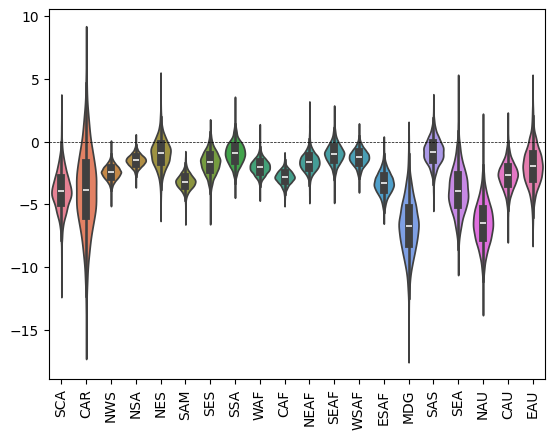

In [14]:
sns.violinplot(spacetrace.posterior.beta.sel(region=negregions).stack(sample=("chain","draw")).T)
plt.xticks(np.arange(len(negregions)),negregions.values,rotation=90)
plt.axhline(0,c="k",ls="--",lw=.5)

Now let's see which model fits the SH data better: different trends in each region or one discrete changepoint (ie, all the data changes over at the same time).

In [15]:
with pm.Model() as negtrendmodel:
    params=spatial.build_spatial_GEV_trend_model(negtrendmodel,negland)
    negtrendtrace=pm.sample()
    negll=pm.compute_log_likelihood(negtrendtrace)

Output()

Output()

In [16]:
with pm.Model() as negswitchmodel:
    params=spatial.build_spatial_GEV_switchpoint_model(negswitchmodel,negland,lower=1998,upper=2024)
    negswitchtrace=pm.sample()
    negsll=pm.compute_log_likelihood(negswitchtrace)

Output()

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Now let's compare the two using PSIS-LOO.  It complains about the pareto_k values because the model fit is highly dependent on certain values- to be expected with we're fitting GEV to extreme values.  This means that the decreasing trends are robust but are driven by the largest observed extremes.

To interpret this table: the elpd_diff (expected log predictive density difference) relative to the se (standard error) is very large: this is strong support for a trend (rather than a switchpoint) model.

In [17]:
az.compare({"trend":negtrendtrace,"switch":negswitchtrace})

/Users/akshayrajeev/anaconda3/envs/pmm/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/akshayrajeev/anaconda3/envs/pmm/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
trend,0,-1747.156805,57.684039,0.000000,1.000000e+00,20.588185,0.000000,True,log
switch,1,-1837.992087,49.812784,90.835283,2.113820e-11,23.009290,14.115215,True,log


## Northern Hemisphere
Now let's look at positive trends in the NH (mostly)

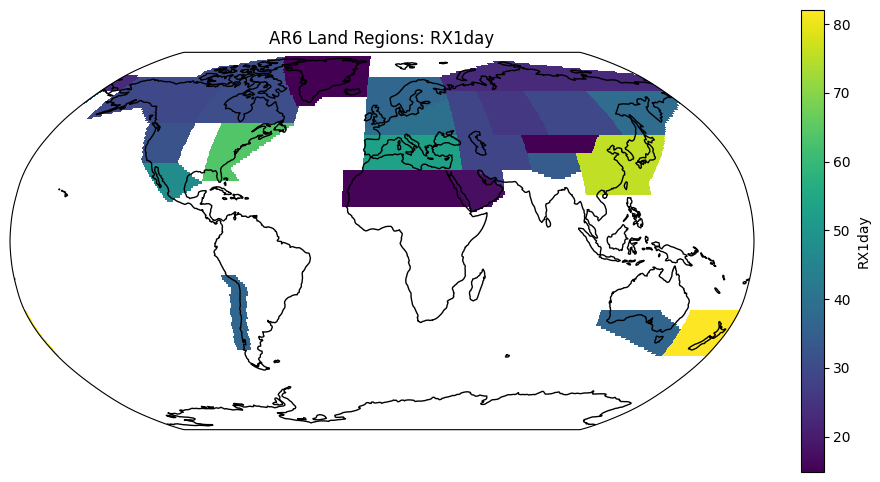

In [18]:

positive_trend=(X.values>-0.2) 
not_antarctica=RX1day_land.mean(dim="time").values>10
posregions=X.region[np.logical_and(positive_trend,not_antarctica)]
#get rid of Antarctica
#posregions=["WAN"]
posland=RX1day_land.sel(region=posregions)
fig=plotting.plot_ar6_land(posland.mean(dim="time"))

In [19]:
with pm.Model() as postrendmodel:
    params=spatial.build_spatial_GEV_trend_model(postrendmodel,posland)
    postrendtrace=pm.sample()
    posl=pm.compute_log_likelihood(postrendtrace)

Output()

Output()

In [20]:
with pm.Model() as posswitchmodel:
    params=spatial.build_spatial_GEV_switchpoint_model(posswitchmodel,posland,lower=1998,upper=2024)
    posswitchtrace=pm.sample()
    possll=pm.compute_log_likelihood(posswitchtrace)

Output()

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

### Comparison
Once again, there is very strong evidence for a trend model as opposed to a switchpoint model!

In [21]:
az.compare({"trend":postrendtrace,"switch":posswitchtrace})

/Users/akshayrajeev/anaconda3/envs/pmm/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/akshayrajeev/anaconda3/envs/pmm/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
trend,0,-1557.651451,68.53933,0.000000,0.925297,21.803512,0.000000,True,log
switch,1,-1659.991143,57.93750,102.339692,0.074703,26.348629,16.785278,True,log


# Ocean

In [22]:
# What about the oceans?

RX1day_ocean_ens=[]
for region in ocean_regions:
    RX1day_ocean_ens+=[ar6models.get_regional_data(region,"RX1day").expand_dims({"region":[region]})]
RX1day_ocean=xr.concat(RX1day_ocean_ens,dim="region")

In [23]:
with pm.Model() as spatialtrendmodel_ocean:
    params=spatial.build_spatial_GEV_trend_model(spatialtrendmodel_ocean,RX1day_ocean)
    spacetrace_ocean=pm.sample()
    pm.compute_log_likelihood(spacetrace_ocean)

Output()

Output()

In [24]:
beta_ocean=spacetrace_ocean.posterior.beta.mean(dim=("chain","draw"))

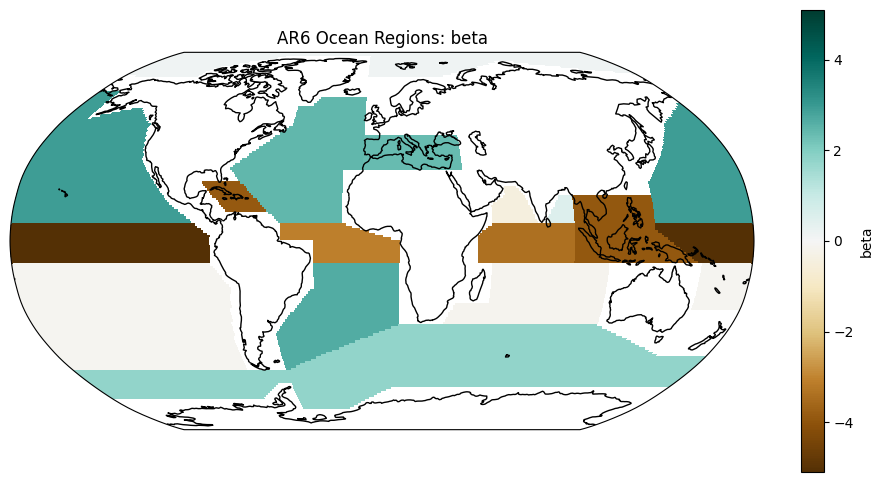

In [25]:
tmp=plotting.plot_ar6_ocean(beta_ocean,cmap="BrBG")

In [26]:
with pm.Model() as spatialswitchmodel_ocean:
    params=spatial.build_spatial_GEV_switchpoint_model(spatialswitchmodel_ocean,RX1day_ocean)
    switchtrace_ocean=pm.sample()
    ll=pm.compute_log_likelihood(switchtrace_ocean)

Output()

There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

In [28]:
az.compare({"ocean trend":spacetrace_ocean,"ocean switchpoint":switchtrace_ocean})

/Users/akshayrajeev/anaconda3/envs/pmm/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/akshayrajeev/anaconda3/envs/pmm/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
ocean trend,0,-1376.847468,44.764777,0.000000,1.000000e+00,22.360160,0.00000,True,log
ocean switchpoint,1,-1547.836170,54.889267,170.988702,1.910097e-10,23.538774,17.43344,True,log
